# Single-calibration siFLIM
This notebook contains an attempt to calculate the siFLIM calibration coefficients using one reference and one calibration file.

# Environment setup commands

* conda install -c conda-forge notebook
* conda install -c conda-forge watermark
* conda install -c conda-forge numpy
* conda install -c conda-forge matplotlib
* conda install -c conda-forge scipy
* pip install fdflim
* pip install flifile

# Computing environment

In [22]:
%load_ext watermark
%watermark -v -p watermark,numpy,matplotlib,scipy,flifile,fdflim

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Python implementation: CPython
Python version       : 3.9.0
IPython version      : 7.19.0

watermark : 2.1.0
numpy     : 1.19.4
matplotlib: 3.3.2
scipy     : 1.5.3
flifile   : 1.2.1
fdflim    : 0.5.1



## Settings

In [58]:
# reference lifetime in units of seconds
reference_lifetime = 3.83E-9

# modulation frequency in units of hertz
modulation_frequency = 40E6

# minimum DC intensity threshold in units of DN
min_threshold = -1 # this is automatically updated two cells down

# maximum DC intensity threshold in units of DN
max_threshold = -1

# minimum and maximum lifetime in colorbars
tau_min = 2
tau_max = 6

# DC normalization factor to increase/reduce normalized DC intensity
DC_normalization_factor = 1.0 # can be updated two cells down

# file paths
base_path = "C:\\Users\Bram\\surfdrive\\Shared\\isiFLIM\\"
filename_reference = "04 siFLIM test 2 dyes\\siFLIM_reference_300ms_Rh6G_3_83ns.fli"
filename_calibration1 = "04 siFLIM test 2 dyes\\siFLIM_reference_300ms_HPTS_5_33ns.fli"
filename_calibration2 = "04 siFLIM test 2 dyes\\siFLIM_reference_300ms_Rh6G+KI_2_60ns.fli"
filename_siflim = "04 siFLIM test 2 dyes\\siFLIM_2phase_timelapse_300ms_90_Rh6G.fli"
#filename_siflim = "04 siFLIM test 2 dyes\\siFLIM_2phase_timelapse_300ms_autoPhase_180_HeLa_H201.fli"

## Helper functions

In [3]:
from flifile import FliFile
from fdflim import Sample, Reference

import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as clr

import scipy.ndimage.filters as flt

from IPython.display import display, clear_output

# combines dual image into single image by averaging top and bottom
def combine_dual_image(dual_image):
    s = dual_image.shape

    if s[1] < 1000:
        return dual_image

    return (dual_image[:, :s[1]//2] + dual_image[:, s[1]//2:])/2

# calculates toggle correction frame F from dual image stack
def toggle_correction_frame(stack):
    mean_stack = np.mean(stack, 2)
    I_T = mean_stack[:, :mean_stack.shape[1]//2].copy()
    I_B = mean_stack[:, mean_stack.shape[1]//2:].copy()
    F = I_T/(I_T + I_B)

    return F

# calculates normalized phase-pair contrast of dual image and 
# applies toggle correction frame
def PPC(dual_image, F):
    s = dual_image.shape
    im_top = dual_image[:, :s[1]//2].astype(np.float64).copy()
    im_bottom = dual_image[:, s[1]//2:].astype(np.float64).copy()
    I_T = im_top - (im_top + im_bottom)*(F - 0.5)
    I_B = im_bottom + (im_top + im_bottom)*(F - 0.5)
    
    # prevent division by zero
    mask = np.where((I_T == 0) & (I_B == 0))
    I_T[mask] = 1
    
    return (I_T - I_B)/(I_T + I_B)

# calculates PPC for entire stack
def calc_PPCs(stack, correction_frame):
    s = stack.shape
    output = np.zeros((s[0], s[1]//2, s[2]))
    
    for phase_idx in range(s[2]):
        output[:, :, phase_idx] = PPC(stack[:, :, phase_idx], correction_frame)
    
    return output

### Load reference

In [4]:
ref_file = FliFile(Path(base_path, filename_reference))
ref_data = ref_file.getdata()
ref = Reference(ref_data, reference_lifetime, modulation_frequency)
print(f"Shape of reference data: {ref_data.shape}")

Shape of reference data: (512, 1008, 24)


### Load sample
The minimum DC intensity threshold is automatically determined here. You can also adjust the normalization factor for the DC image here.

In [24]:
sam_file1 = FliFile(Path(base_path, filename_calibration1))
sam_file2 = FliFile(Path(base_path, filename_calibration2))
sam_data1 = sam_file1.getdata()
sam_data2 = sam_file2.getdata()
sam1 = Sample(sam_data1, ref)
sam2 = Sample(sam_data2, ref)
print(f"Shape of sample data: {sam_data1.shape}")

Shape of sample data: (512, 1008, 24)


### Update minimum DC intensity threshold

Mean sample background intensity: 325.15 DN
Setting min_threshold to 650 DN


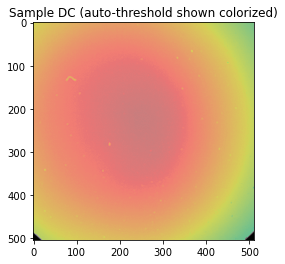

In [25]:
sam_bg = combine_dual_image(sam_file1.getbackground())
mean_bg = np.mean(sam_bg.ravel())
print(f"Mean sample background intensity: {mean_bg:.2f} DN")
min_threshold = int(2*mean_bg)
print(f"Setting min_threshold to {min_threshold} DN")

im_DC = combine_dual_image(sam1.dc.copy())
im_DC_thresholded = im_DC.copy()
mask = np.where(im_DC < min_threshold)
im_DC_thresholded[mask] = np.nan

fig = plt.figure()
plt.imshow(im_DC.transpose(), cmap="gray")
plt.imshow(im_DC_thresholded.transpose(), cmap="jet", alpha=0.5)
plt.title("Sample DC (auto-threshold shown colorized)")
plt.show()

normalized_DC = im_DC.copy()/np.max(im_DC.ravel())

### Set DC intensity normalization factor

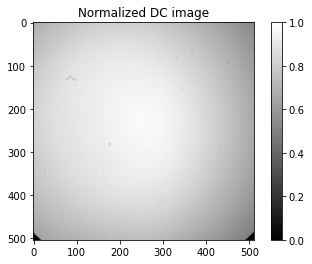

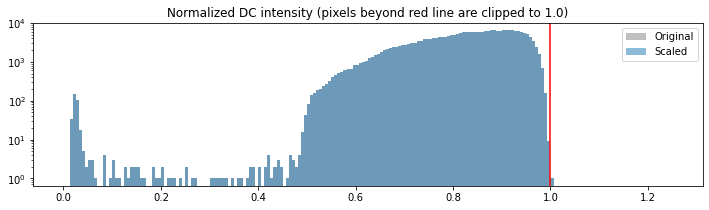

In [26]:
DC_normalization_factor = 1.0
normalized_DC_scaled = normalized_DC*DC_normalization_factor

fig = plt.figure()
plt.imshow(normalized_DC_scaled.transpose(), cmap="gray")
plt.colorbar()
plt.clim([0, 1])
plt.title("Normalized DC image")
plt.show()

fig = plt.figure(figsize=(12,3))
plt.hist(normalized_DC.ravel(), bins=200, range=(0, 1.25), color="gray", alpha=0.5, log=True, label="Original")
plt.hist(normalized_DC_scaled.ravel(), bins=200, range=(0, 1.25), alpha=0.5, log=True, label="Scaled")
plt.axvline(x=1, color="red")
plt.title("Normalized DC intensity (pixels beyond red line are clipped to 1.0)")
plt.legend()
plt.show()

## Calculate lifetime
Calculate phase lifetime using 24-phase stack.

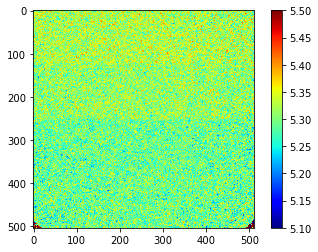

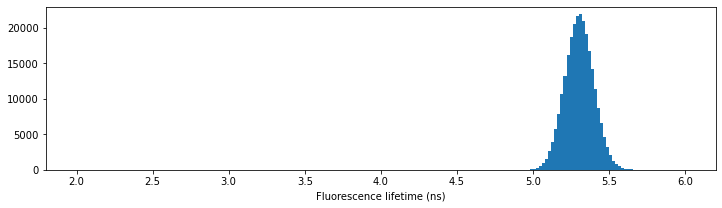

In [69]:
DC1 = combine_dual_image(sam1.dc)
tau1 = combine_dual_image(sam1.getlifetimephase())

fig = plt.figure()
fig.patch.set_facecolor("white")
plt.imshow(tau1.transpose()*1E9, cmap="jet")
plt.clim([5.1, 5.5])
plt.colorbar()
plt.show()

fig = plt.figure(figsize=(12,3))
plt.hist(tau1.ravel()*1E9, bins=200, range=(tau_min, tau_max))
plt.xlabel("Fluorescence lifetime (ns)")
plt.show()

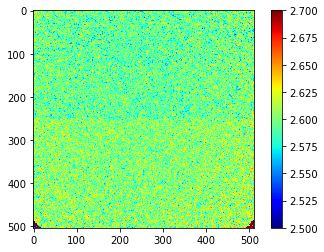

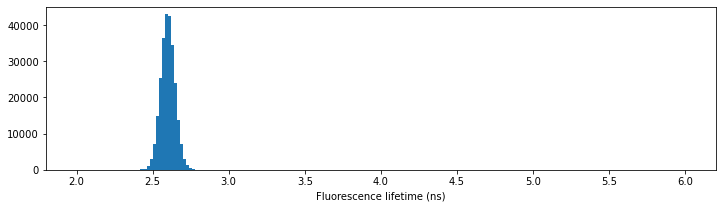

In [70]:
DC2 = combine_dual_image(sam2.dc)
tau2 = combine_dual_image(sam2.getlifetimephase())

fig = plt.figure()
fig.patch.set_facecolor("white")
plt.imshow(tau2.transpose()*1E9, cmap="jet")
plt.clim([2.5, 2.7])
plt.colorbar()
plt.show()

fig = plt.figure(figsize=(12,3))
plt.hist(tau2.ravel()*1E9, bins=200, range=(tau_min, tau_max))
plt.xlabel("Fluorescence lifetime (ns)")
plt.show()

## Calculate toggle correction frame

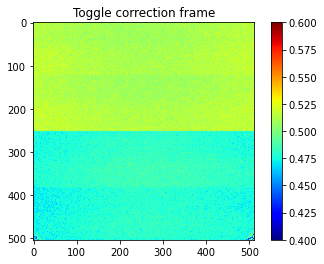

In [33]:
F = toggle_correction_frame(ref_data)

fig = plt.figure()
plt.imshow(F.transpose(), cmap="jet")
plt.colorbar()
plt.clim([0.4, 0.6])
plt.title("Toggle correction frame")
plt.show()

## Calculate PPCs
A median filter is applied to the PPCs to reduce the effects of noise for fitting purposes.

In [85]:
ref_PPC = calc_PPCs(ref_data, F)
ref_PPC = flt.median_filter(ref_PPC, 5)

sam_PPC1 = calc_PPCs(sam_data1, F)
sam_PPC1 = flt.median_filter(sam_PPC1, 5)
corrected_PPC1 = sam_PPC1 - ref_PPC

sam_PPC2 = calc_PPCs(sam_data2, F)
sam_PPC2 = flt.median_filter(sam_PPC2, 5)
corrected_PPC2 = sam_PPC2 - ref_PPC

## Apply threshold

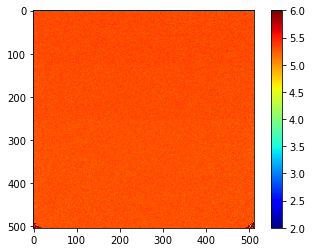

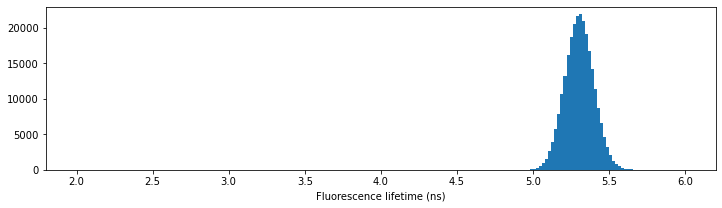

In [86]:
if min_threshold > 0:
    mask = np.where(DC1 < min_threshold)
    tau1[mask] = np.nan
    corrected_PPC1[mask] = np.nan

if max_threshold > 0:
    mask = np.where(DC1 > max_threshold)
    tau1[mask] = np.nan
    corrected_PPC1[mask] = np.nan

if min_threshold > 0:
    mask = np.where(DC2 < min_threshold)
    tau2[mask] = np.nan
    corrected_PPC2[mask] = np.nan

if max_threshold > 0:
    mask = np.where(DC2 > max_threshold)
    tau2[mask] = np.nan
    corrected_PPC2[mask] = np.nan

fig = plt.figure()
plt.imshow(tau1.transpose()*1E9, cmap="jet")
plt.clim([tau_min, tau_max])
plt.colorbar()
plt.show()
    
fig = plt.figure(figsize=(12,3))
plt.hist(tau1.ravel()*1E9, bins=200, range=(tau_min, 6))
plt.xlabel("Fluorescence lifetime (ns)")
plt.show()

In [87]:
tau = np.concatenate([tau1,tau2])
corrected_PPC = np.concatenate([corrected_PPC1,corrected_PPC2])
print(tau.shape)

(1024, 504)


## Calculate calibration coefficients
Please note that the cell below sometimes throws this exception: `SVD did not converge in Linear Least Squares`. This is a known issue of `polyfit()`, a workaround is to just run the cell again.

In [88]:
# use OpenCV fitLine when implementing in LIFA: https://docs.opencv.org/2.4/modules/imgproc/doc/structural_analysis_and_shape_descriptors.html?highlight=fitline#fitline
tau_list = tau[np.isfinite(tau)]
PPC_list = corrected_PPC[np.isfinite(tau)]

coefficients = np.zeros((2, PPC_list.shape[1]))

# !THIS SOMETIMES THROWS AN EXCEPTION!
# Just run this cell again when that happens, it's a known issue of polyfit()
for phase_idx in range(PPC_list.shape[1]):
    coefficients[:, phase_idx] = np.polyfit(PPC_list[:, phase_idx], tau_list, 1)

phase_indices = np.arange(PPC_list.shape[1])

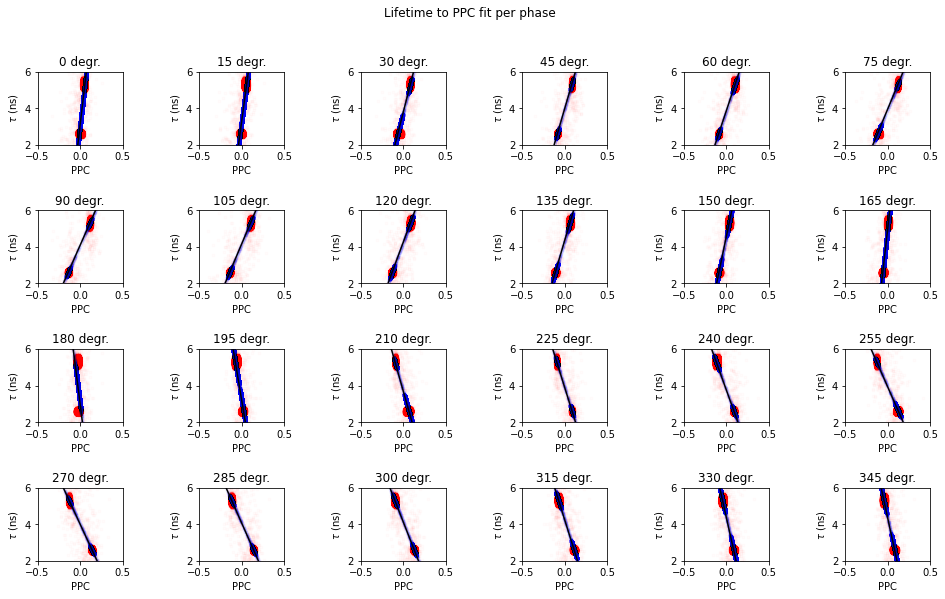

In [89]:
max_idx = np.argmax(coefficients[0, :])

x_fit = np.arange(-1, 1, 0.1)

tau_difference = np.zeros(PPC_list.shape[1])
tau_RMS = np.zeros(PPC_list.shape[1])

fig = plt.figure(figsize=(16, 9))
fig.patch.set_facecolor("white")
plt.suptitle("Lifetime to PPC fit per phase")
for phase_idx in range(PPC_list.shape[1]):
    y_fit = np.polyval(coefficients[:, phase_idx], x_fit)
    tau_fit = PPC_list[:, phase_idx]*coefficients[0, phase_idx] + coefficients[1, phase_idx]

    plt.subplot(4, 6, phase_idx + 1)
    plt.plot(PPC_list[:, phase_idx], tau_list*1E9, 'r.', alpha=0.01)
    plt.plot(PPC_list[:, phase_idx], tau_fit*1E9, 'b.', alpha=0.01)
    plt.plot(x_fit, y_fit*1E9, '-k')
    plt.title(f"{phase_idx*15} degr.")
    plt.xlim([-0.5, 0.5])
    plt.ylim([tau_min, tau_max])
    plt.xlabel("PPC")
    plt.ylabel(r"$\tau$ (ns)")
    
    tau_difference[phase_idx] = np.mean((tau_fit - tau_list))
    tau_RMS[phase_idx] = np.sqrt(np.mean((tau_fit - tau_list).ravel()**2))

plt.subplots_adjust(wspace=0.9, hspace=0.9)
plt.show()

### Calculate difference between 24-phase lifetime and siFLIM lifetime
This might be useful in the future to choose the optimal siFLIM phase.

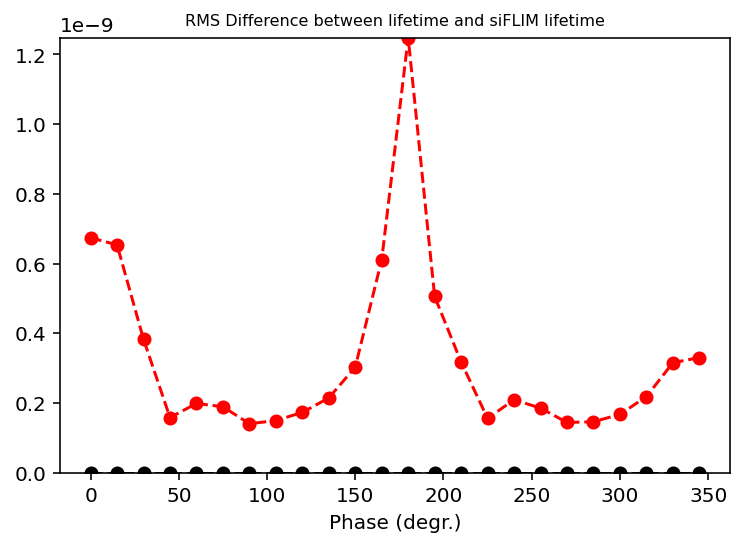

Maximum slope at phase index 11 (165 degr.)
Minimum difference at phase index 7 (105 degr.)
Mean 24-phase lifetime: 3.95 ns
Value of omega*(mean tau): 0.99


In [90]:
fig = plt.figure(dpi=144)
plt.plot(np.arange(PPC_list.shape[1])*15, tau_difference, '--ko')
plt.plot(np.arange(PPC_list.shape[1])*15, tau_RMS, '--ro')
plt.title("RMS Difference between lifetime and siFLIM lifetime", fontsize=8)
plt.xlabel("Phase (degr.)")
plt.ylim([0,max(tau_RMS)])
plt.show()

print(f"Maximum slope at phase index {max_idx} ({max_idx*15} degr.)")

min_diff_idx = np.argmin(tau_difference)
print(f"Minimum difference at phase index {min_diff_idx} ({min_diff_idx*15} degr.)")

mean_tau = np.mean(tau_list.ravel())
print(f"Mean 24-phase lifetime: {mean_tau*1E9:.2f} ns")

omega = 2*np.pi*modulation_frequency
print(f"Value of omega*(mean tau): {omega*mean_tau:.2f}")

## Test calibration constants for each phase in 24-phase sample

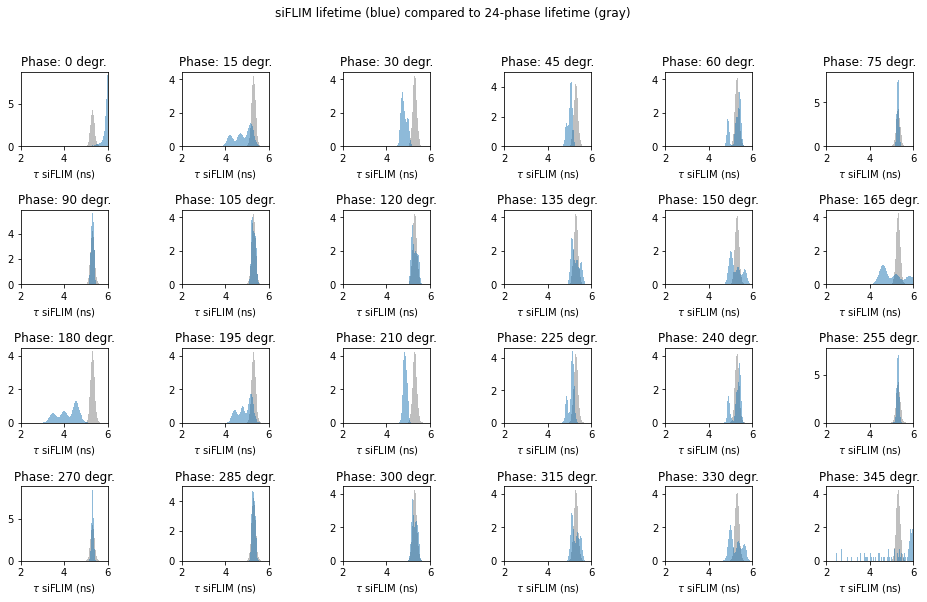

In [95]:
fig = plt.figure(figsize=(16, 9))
fig.patch.set_facecolor("white")
fig.suptitle("siFLIM lifetime (blue) compared to 24-phase lifetime (gray)")

for phase_idx in range(PPC_list.shape[1]):
    dual_image = sam_data1[:, :, phase_idx]
    phase_PPC = flt.median_filter(PPC(dual_image, F), 5) - ref_PPC[:, :, phase_idx]
    tau_siflim_phase = phase_PPC*coefficients[0, phase_idx] + coefficients[1, phase_idx]
    
    plt.subplot(4, 6, phase_idx + 1)
    plt.hist(tau1.ravel()*1E9, bins=200, label="24-phase lifetime", color="gray", alpha=0.5, range=(tau_min, tau_max), density=True)
    plt.hist(tau_siflim_phase.ravel()*1E9, bins=200, label="siFLIM lifetime", range=(tau_min, tau_max), alpha=0.5, density=True)
    plt.xlim((tau_min, tau_max))
#    plt.imshow(tau_siflim_phase.transpose())
#    plt.clim([3e-9,6e-9])
    plt.title(f"Phase: {phase_idx*15} degr.")
    plt.xlabel(r"$\tau$ siFLIM (ns)")

plt.subplots_adjust(wspace=0.85, hspace=0.85)
plt.show()

## Load siFLIM data

In [59]:
siflim_file = FliFile(Path(base_path, filename_siflim))
siflim_phase_idx = int(siflim_file.header['PARAMETERS']['ACQUISITION SETTINGS']['siflimAcquisitionPhase'])//15
print(f"siFLIM data was recorded with phase index {siflim_phase_idx} ({siflim_phase_idx*15} degr.)")

siFLIM data was recorded with phase index 6 (90 degr.)


In [60]:
siflim_data = siflim_file.getdata()
print(f"Shape of siFLIM data: {siflim_data.shape}")
siflim_data = siflim_data[:,:,1,1::10]
print(f"Shape of siFLIM data: {siflim_data.shape}")

Shape of siFLIM data: (512, 1008, 2, 99)
Shape of siFLIM data: (512, 1008, 10)


### Process siFLIM time-lapse
Process each frame in the time-lapse and save siFLIM lifetime overlay image to subfolder with the name of the siFLIM time-lapse file.

In [65]:
dir_output = Path(base_path, f"{filename_siflim}-output")
if not os.path.exists(dir_output):
    os.makedirs(dir_output)

C1 = coefficients[0, siflim_phase_idx]
if siflim_phase_idx*15 > 180:
    pass
#    C1 = np.abs(C1)
C2 = coefficients[1, siflim_phase_idx]

print(f"siFLIM coefficients for phase {siflim_phase_idx*15}:\n\tC1 = {C1}\n\tC2 = {C2}")

timestamps = siflim_file.header['FLIMIMAGE']['TIMESTAMPS']
t0 = float(timestamps['t0'].replace(' ', ''))

siFLIM coefficients for phase 90:
	C1 = 1.0554636295507093e-08
	C2 = 4.079630318499279e-09


In [64]:
for frame_idx in range(siflim_data.shape[2]):
    clear_output(wait=True)
    display(f"Processing frame {frame_idx} of {siflim_data.shape[2]}")

    # calculate elapsed time of current frame in time-lapse
    timestamp = float(timestamps[f"t{frame_idx}"].replace(' ', ''))
    elapsed = (timestamp - t0)/1E7
        
    frame_PPC = PPC(siflim_data[:, :, frame_idx], F)
    frame_DC = combine_dual_image(siflim_data[:, :, frame_idx])
    
    # correct PPC using reference PPC
    if siflim_phase_idx*15 >= 180:
        frame_PPC += ref_PPC[:, :, siflim_phase_idx]
    else:
        frame_PPC -= ref_PPC[:, :, siflim_phase_idx]

    frame_PPC = flt.median_filter(frame_PPC, 5)
    tau_siflim = frame_PPC*C1 + C2
    print(np.mean(tau_siflim))
    # normalize DC image, clip value at a maximum of 1.0
    frame_DC = DC_normalization_factor*frame_DC/np.max(frame_DC.ravel())
    frame_DC[np.where(frame_DC > 1.0)] = 1.0
    frame_DC = frame_DC.transpose()
    
    # convert siFLIM lifetime to units of ns
    tau_map = tau_siflim.copy()*1E9
    tau_map = tau_map.transpose()
    
    # create lifetime colormap
    tau_map -= tau_min
    tau_map /= (tau_max - tau_min)
    im_RGBA = cm.jet(tau_map)
    
    # remove fourth dimension (transparency value)
    im_RGB = np.delete(im_RGBA, 3, axis=2)
    
    # insert DC intensity in intensity channel
    im_HSV = clr.rgb_to_hsv(im_RGB)
    im_HSV[:, :, 2] = frame_DC
    im_RGB = clr.hsv_to_rgb(im_HSV)
    
    fig = plt.figure(dpi=200)
    plt.imshow(im_RGB, cmap="jet")
    cbarTicks = np.arange(tau_min, tau_max + 0.9, 1)
    cbarTicksNormalized = np.divide(cbarTicks, tau_max - tau_min)
    cbar = plt.colorbar(ticks=[0, 1], fraction=0.046, pad=0.01, aspect=20)
    plt.clim(0, 1) # lock color scale (lifetime values are normalized)
    cbar.ax.minorticks_on()
    cbar.update_ticks()
    cbar.ax.set_yticklabels([str(tau_min) + " ns", str(tau_max) + " ns"])
    cbar.ax.tick_params(labelsize=10)
    plt.axis("off")
    plt.title(f"siFLIM lifetime (elapsed time: {elapsed:.2f} s)", fontsize=8)
    plt.savefig(dir_output / f"frame{frame_idx:04d}.png", bbox_inches="tight")
    plt.close()

clear_output(wait=True)
display("Done!")

'Done!'